##AFCON 2023 Final — Match Analysis Report
# Nigeria vs Côte d'Ivoire
Date: 11 February 2024 | Stade Olympique Alassane Ouattara, Abidjan

Prepared by Abdelrhman Madian | Football Data Analyst

In [3]:
!pip install mplsoccer statsbombpy -q

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch
from statsbombpy import sb

# Check AFCON 2023 availability
competitions = sb.competitions()
afcon = competitions[competitions['competition_name'].str.contains('Africa', case=False)]
print(afcon[['competition_id', 'season_id', 'competition_name', 'season_name']])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00
   competition_id  season_id        competition_name season_name
2            1267        107  African Cup of Nations        2023


In [4]:
matches = sb.matches(competition_id=1267, season_id=107)
print(f"Total matches: {len(matches)}")
print(matches[['match_id', 'home_team', 'away_team', 'match_date']].to_string())

Total matches: 52
    match_id           home_team           away_team  match_date
0    3923881             Nigeria       Côte d'Ivoire  2024-02-11
1    3923880        South Africa            Congo DR  2024-02-10
2    3922838       Côte d'Ivoire            Congo DR  2024-02-07
3    3922837             Nigeria        South Africa  2024-02-07
4    3922242             Senegal       Côte d'Ivoire  2024-01-29
5    3922239   Equatorial Guinea              Guinea  2024-01-28
6    3922659                Mali       Côte d'Ivoire  2024-02-03
7    3922658  Cape Verde Islands        South Africa  2024-02-03
8    3922244                Mali        Burkina Faso  2024-01-30
9    3922356            Congo DR              Guinea  2024-02-02
10   3922321             Nigeria              Angola  2024-02-02
11   3922237              Angola             Namibia  2024-01-27
12   3922243             Morocco        South Africa  2024-01-30
13   3922241  Cape Verde Islands          Mauritania  2024-01-29
14   39

In [18]:
match_id_final = 3923881
events_final = sb.events(match_id=match_id_final)

home_final = matches[matches['match_id'] == match_id_final].iloc[0]['home_team']
away_final = matches[matches['match_id'] == match_id_final].iloc[0]['away_team']

print(f"Match: {home_final} vs {away_final}")
print(f"Total events: {len(events_final)}")
print(events_final['type'].value_counts())

Match: Nigeria vs Côte d'Ivoire
Total events: 2699
type
Pass                 736
Ball Receipt*        704
Carry                553
Pressure             197
Ball Recovery         90
Clearance             64
Duel                  51
Foul Committed        34
Foul Won              32
Goal Keeper           28
Dribble               28
Block                 27
Miscontrol            27
Shot                  23
Injury Stoppage       19
Dribbled Past         15
Dispossessed          10
Substitution          10
Interception           9
Referee Ball-Drop      9
50/50                  5
Bad Behaviour          4
Half Start             4
Player Off             4
Player On              4
Tactical Shift         4
Half End               4
Starting XI            2
Shield                 2
Name: count, dtype: int64


Côte d'Ivoire shots: 18 | xG: 1.41 | Goals: 2
Nigeria shots: 5 | xG: 0.26 | Goals: 1


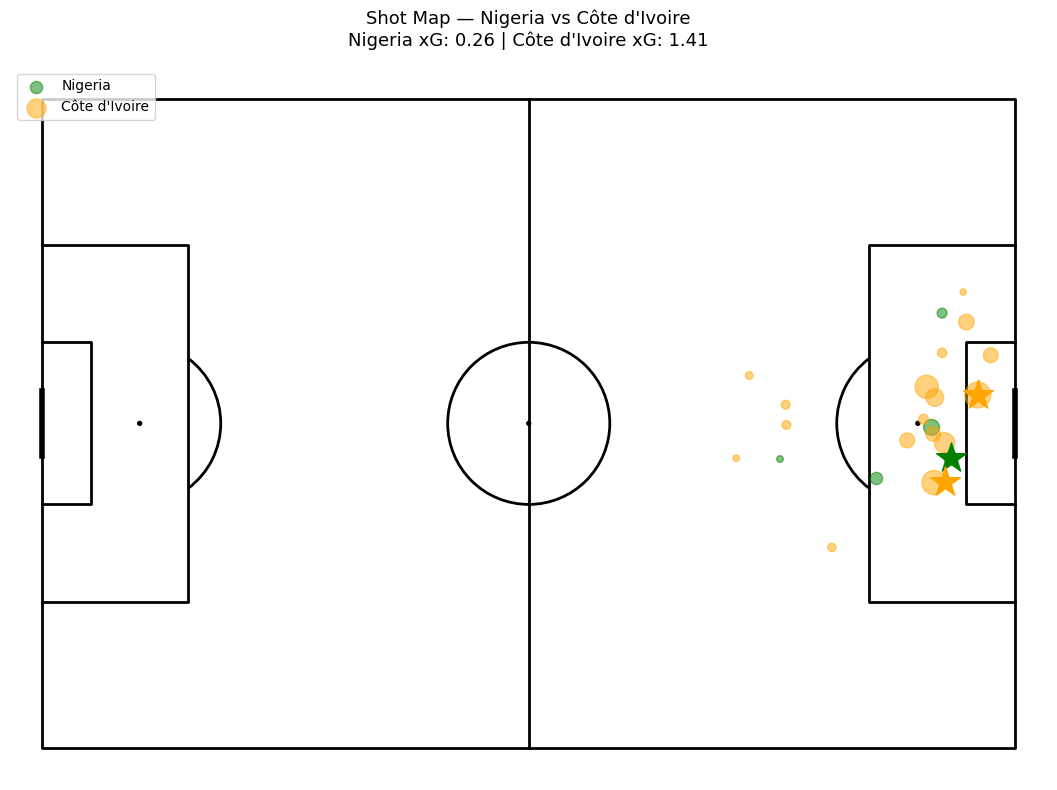

In [19]:
shots_final = events_final[events_final['type'] == 'Shot'].copy()
shots_final['x'] = shots_final['location'].apply(lambda loc: loc[0])
shots_final['y'] = shots_final['location'].apply(lambda loc: loc[1])

# Filter out penalties
shots_open = shots_final[shots_final['shot_type'] != 'Penalty']

ci_shots = shots_open[shots_open['team'] == 'Côte d\'Ivoire']
nigeria_shots = shots_open[shots_open['team'] == 'Nigeria']

ci_goals = ci_shots[ci_shots['shot_outcome'] == 'Goal']
nigeria_goals = nigeria_shots[nigeria_shots['shot_outcome'] == 'Goal']

ci_xg = ci_shots['shot_statsbomb_xg'].sum()
nigeria_xg = nigeria_shots['shot_statsbomb_xg'].sum()

print(f"Côte d'Ivoire shots: {len(ci_shots)} | xG: {ci_xg:.2f} | Goals: {len(ci_goals)}")
print(f"Nigeria shots: {len(nigeria_shots)} | xG: {nigeria_xg:.2f} | Goals: {len(nigeria_goals)}")

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(12, 8))

pitch.scatter(nigeria_shots['x'], nigeria_shots['y'], ax=ax,
              s=nigeria_shots['shot_statsbomb_xg']*1500,
              color='green', alpha=0.5, label='Nigeria')
pitch.scatter(nigeria_goals['x'], nigeria_goals['y'], ax=ax,
              s=500, color='green', marker='*', zorder=5)

pitch.scatter(ci_shots['x'], ci_shots['y'], ax=ax,
              s=ci_shots['shot_statsbomb_xg']*1500,
              color='orange', alpha=0.5, label="Côte d'Ivoire")
pitch.scatter(ci_goals['x'], ci_goals['y'], ax=ax,
              s=500, color='orange', marker='*', zorder=6)

ax.set_title(f"Shot Map — Nigeria vs Côte d'Ivoire\nNigeria xG: {nigeria_xg:.2f} | Côte d'Ivoire xG: {ci_xg:.2f}",
             fontsize=13, pad=15)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('afcon_shot_map.png', dpi=200, bbox_inches='tight')
plt.show()

Côte d'Ivoire passes: 464
Nigeria passes: 272

Côte d'Ivoire pass accuracy: 83.6%
Nigeria pass accuracy: 69.5%


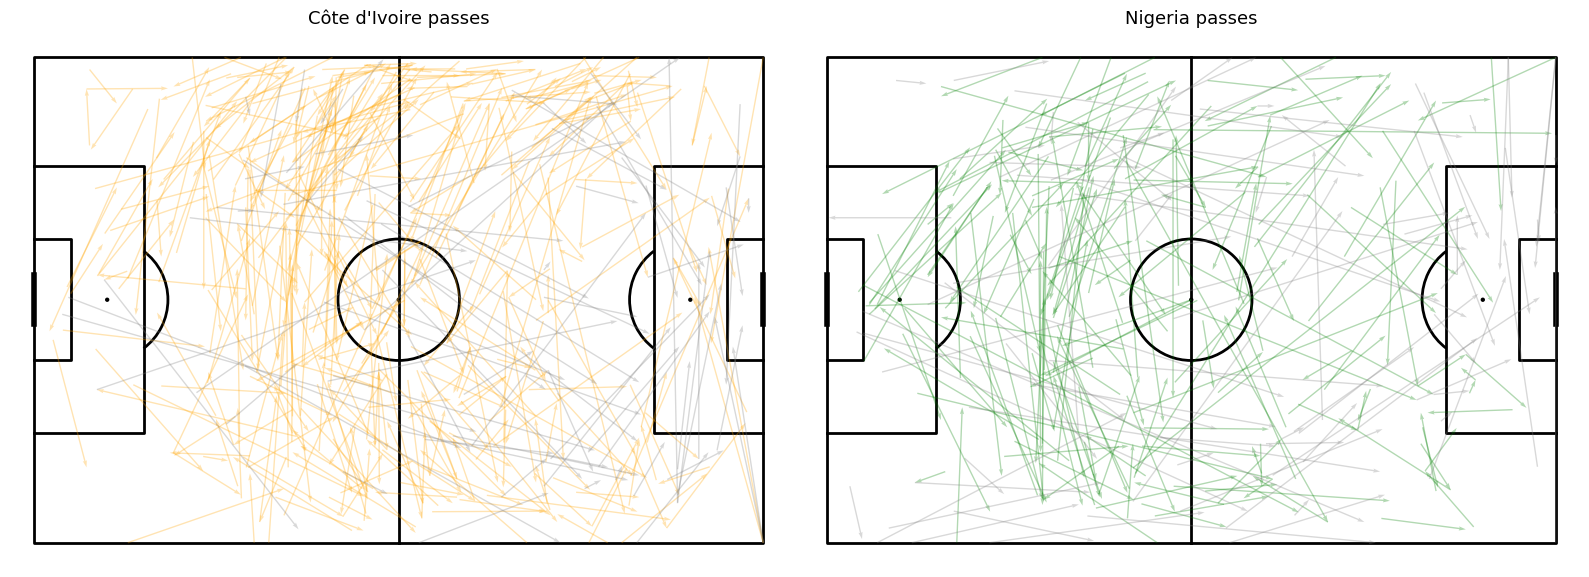

In [20]:
passes_final = events_final[events_final['type'] == 'Pass'].copy()
passes_final['x'] = passes_final['location'].apply(lambda loc: loc[0])
passes_final['y'] = passes_final['location'].apply(lambda loc: loc[1])
passes_final['end_x'] = passes_final['pass_end_location'].apply(lambda loc: loc[0])
passes_final['end_y'] = passes_final['pass_end_location'].apply(lambda loc: loc[1])

ci_passes = passes_final[passes_final['team'] == "Côte d'Ivoire"]
nigeria_passes = passes_final[passes_final['team'] == 'Nigeria']

print(f"Côte d'Ivoire passes: {len(ci_passes)}")
print(f"Nigeria passes: {len(nigeria_passes)}")
print(f"\nCôte d'Ivoire pass accuracy: {(ci_passes['pass_outcome'].isna().sum() / len(ci_passes) * 100):.1f}%")
print(f"Nigeria pass accuracy: {(nigeria_passes['pass_outcome'].isna().sum() / len(nigeria_passes) * 100):.1f}%")

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, axes = pitch.draw(ncols=2, figsize=(16, 8))

for ax, team_passes, team_name, color in [
    (axes[0], ci_passes, "Côte d'Ivoire", 'orange'),
    (axes[1], nigeria_passes, 'Nigeria', 'green')
]:
    complete = team_passes[team_passes['pass_outcome'].isna()]
    incomplete = team_passes[team_passes['pass_outcome'].notna()]
    pitch.arrows(complete['x'], complete['y'], complete['end_x'], complete['end_y'],
                 ax=ax, color=color, alpha=0.3, width=1)
    pitch.arrows(incomplete['x'], incomplete['y'], incomplete['end_x'], incomplete['end_y'],
                 ax=ax, color='gray', alpha=0.3, width=1)
    ax.set_title(f'{team_name} passes', fontsize=13)

plt.tight_layout()
plt.savefig('afcon_pass_map.png', dpi=200, bbox_inches='tight')
plt.show()

Côte d'Ivoire pressures: 87
Nigeria pressures: 110


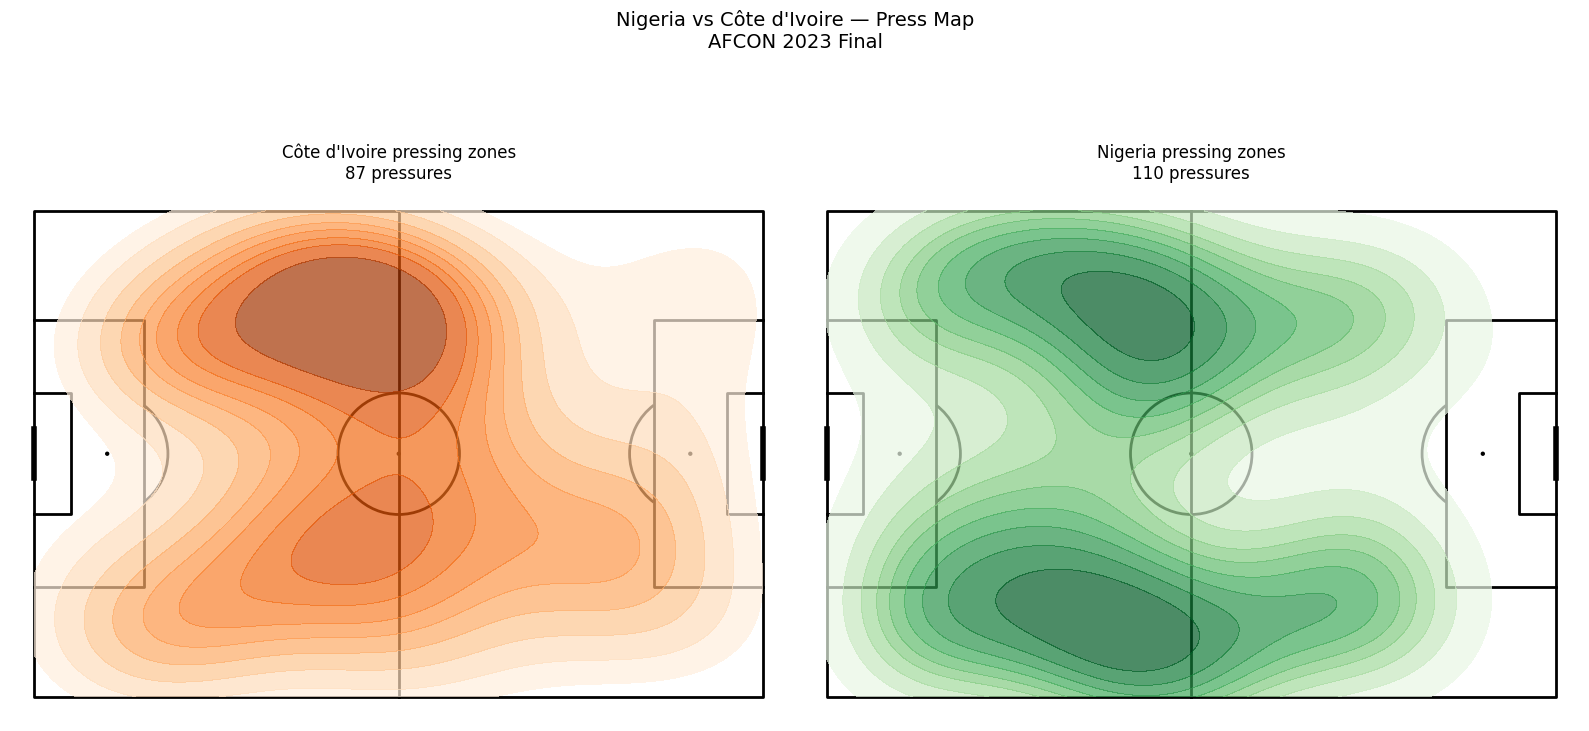

In [21]:
pressure_final = events_final[events_final['type'] == 'Pressure'].copy()
pressure_final['x'] = pressure_final['location'].apply(lambda loc: loc[0])
pressure_final['y'] = pressure_final['location'].apply(lambda loc: loc[1])

ci_press = pressure_final[pressure_final['team'] == "Côte d'Ivoire"]
nigeria_press = pressure_final[pressure_final['team'] == 'Nigeria']

print(f"Côte d'Ivoire pressures: {len(ci_press)}")
print(f"Nigeria pressures: {len(nigeria_press)}")

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, axes = pitch.draw(ncols=2, figsize=(16, 8))

pitch.kdeplot(ci_press['x'], ci_press['y'], ax=axes[0],
              fill=True, cmap='Oranges', levels=10, alpha=0.7)
axes[0].set_title(f"Côte d'Ivoire pressing zones\n{len(ci_press)} pressures", fontsize=12)

pitch.kdeplot(nigeria_press['x'], nigeria_press['y'], ax=axes[1],
              fill=True, cmap='Greens', levels=10, alpha=0.7)
axes[1].set_title(f"Nigeria pressing zones\n{len(nigeria_press)} pressures", fontsize=12)

plt.suptitle("Nigeria vs Côte d'Ivoire — Press Map\nAFCON 2023 Final", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('afcon_press_map.png', dpi=200, bbox_inches='tight')
plt.show()

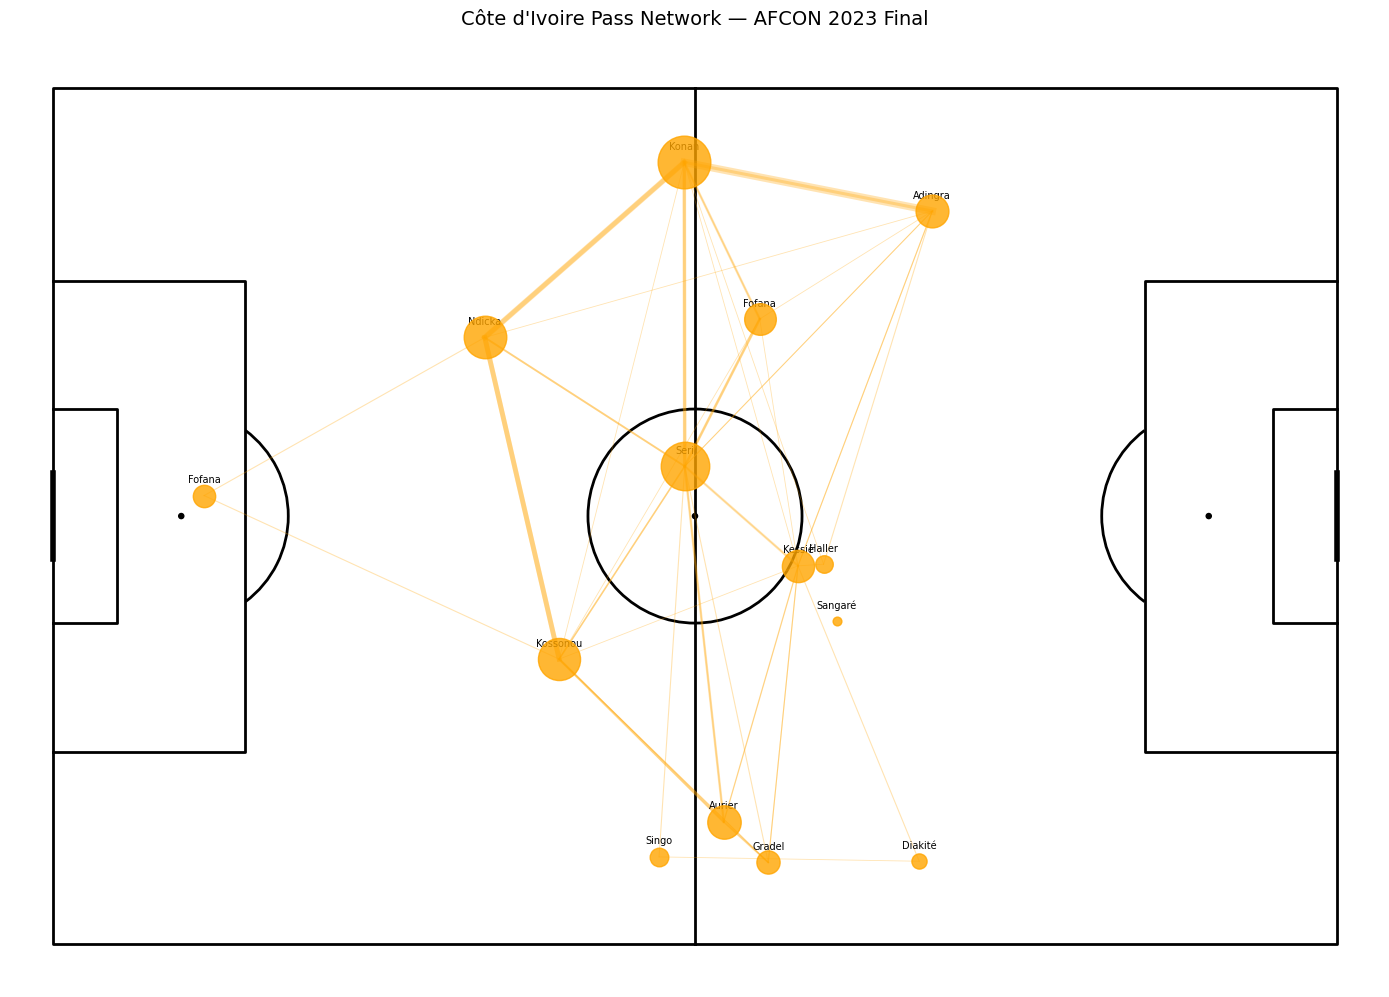

In [22]:
passes_ci = passes_final[
    (passes_final['team'] == "Côte d'Ivoire") &
    (passes_final['pass_outcome'].isna())
].copy()

passes_ci['x'] = passes_ci['location'].apply(lambda loc: loc[0])
passes_ci['y'] = passes_ci['location'].apply(lambda loc: loc[1])

player_positions = passes_ci.groupby('player').agg(
    x=('x', 'mean'),
    y=('y', 'mean'),
    count=('x', 'count')
).reset_index()

combos = passes_ci.groupby(['player', 'pass_recipient']).size().reset_index(name='pass_count')
combos = combos[combos['pass_count'] >= 3]

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(14, 10))

for _, row in combos.iterrows():
    if row['player'] in player_positions['player'].values and \
       row['pass_recipient'] in player_positions['player'].values:
        p1 = player_positions[player_positions['player'] == row['player']].iloc[0]
        p2 = player_positions[player_positions['player'] == row['pass_recipient']].iloc[0]
        ax.plot([p1['x'], p2['x']], [p1['y'], p2['y']],
                color='orange', alpha=0.3, linewidth=row['pass_count'] * 0.2)

for _, player in player_positions.iterrows():
    ax.scatter(player['x'], player['y'],
               s=player['count'] * 20, color='orange', alpha=0.8, zorder=5)
    ax.annotate(player['player'].split()[-1],
                (player['x'], player['y']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_title("Côte d'Ivoire Pass Network — AFCON 2023 Final", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('afcon_pass_network.png', dpi=200, bbox_inches='tight')
plt.show()

The shot map shows Côte d'Ivoire created more than triple Nigeria's chances — 18 shots to 5 — resulting in an xG of 1.41 compared to Nigeria's 0.26, meaning Côte d'Ivoire generated more than five times the expected goal threat. The pass map confirms this dominance — Côte d'Ivoire completed 464 passes at 83.6% accuracy, nearly double Nigeria's 272 passes at 69.5%. Both teams built from high defenders but Nigeria frequently went direct with long balls, reflecting their counter-attacking approach. The press map shows Nigeria pressed more intensively with 110 pressure actions concentrated on both wings in Côte d'Ivoire's half, trying to cut off their wide outlets. Côte d'Ivoire pressed less with 87 actions, focused on the left side of the middle third. The pass network explains exactly why Nigeria targeted the wings — Côte d'Ivoire's build-up ran through a triangle of Seri at CDM, Aurier at right back, and Konan at left back, with Seri as the most connected player and the left side as the primary route forward. Nigeria's 2-1 scoreline flattered them — all the data confirms Côte d'Ivoire deserved to win and controlled the match from start to finish.